# Домашнее задание 2. Библиотеки для визуализаций в Python

Задание выполнил(а):
Филипп Шульц

## Общая информация

__Внимание!__  

Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов. Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов.

Каждое задание весит 0.5 или 1 балл (указано рядом с номером задания). Всего в сумме можно получить, если правильно решить все задания, 10 баллов.

## Раздел 1. Визуализации в датасете кредитного скоринга

### О задании

Вы будете работать с задачей кредитного скоринга (оценка надёжности клиента). Предоставляются данные о 1000 клиентов, про которых известно около 20 признаков и положительная или отрицательная оценка в качестве кредитуемого. Эти данные нужно исследовать с помощью средств визуализации.

*Описание данных*:
https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Каждый построенный график необходимо красиво оформить – для этого требуется как минимум указать его название, а также отметить, что изображено по каждой из осей.
Также по каждому графику ожидается небольшой комментарий с выводами.

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
GERMAN_CREDIT = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
GERMAN_CREDIT_DF = pd.read_csv(GERMAN_CREDIT)

### Задание 1 (0.5 балла)

Используя `numpy` и `matplotlib`, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ на интервале от $-\pi$ до $\pi$, используя 100 точек. Добавьте легенду и сетку.. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться примерно как на картинке. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

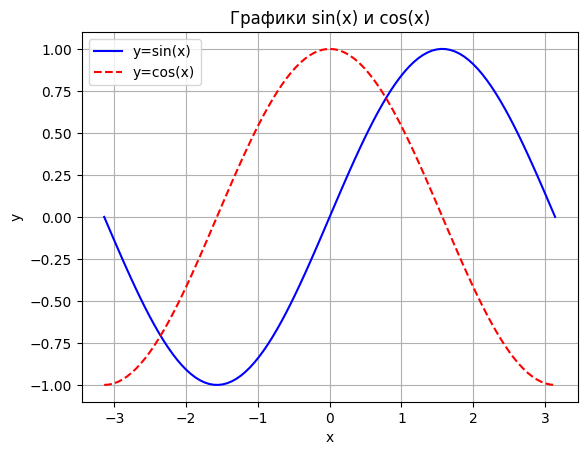

In [63]:
# ваш код здесь

x = np.linspace(-np.pi, np.pi, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.figure()
plt.plot(x, y_sin, label='y=sin(x)', color='blue')
plt.plot(x, y_cos, label='y=cos(x)', color='red', linestyle='--')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Графики sin(x) и cos(x)')
plt.legend()
plt.grid(True)

plt.show()



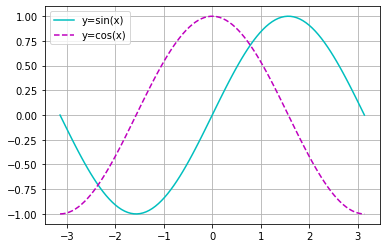

In [ ]:
# то что должно получиться

### Задание 2 (0.5 балла)

Прочитайте средствами pandas файл с данными кредитного скоринга. Рассмотрите сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

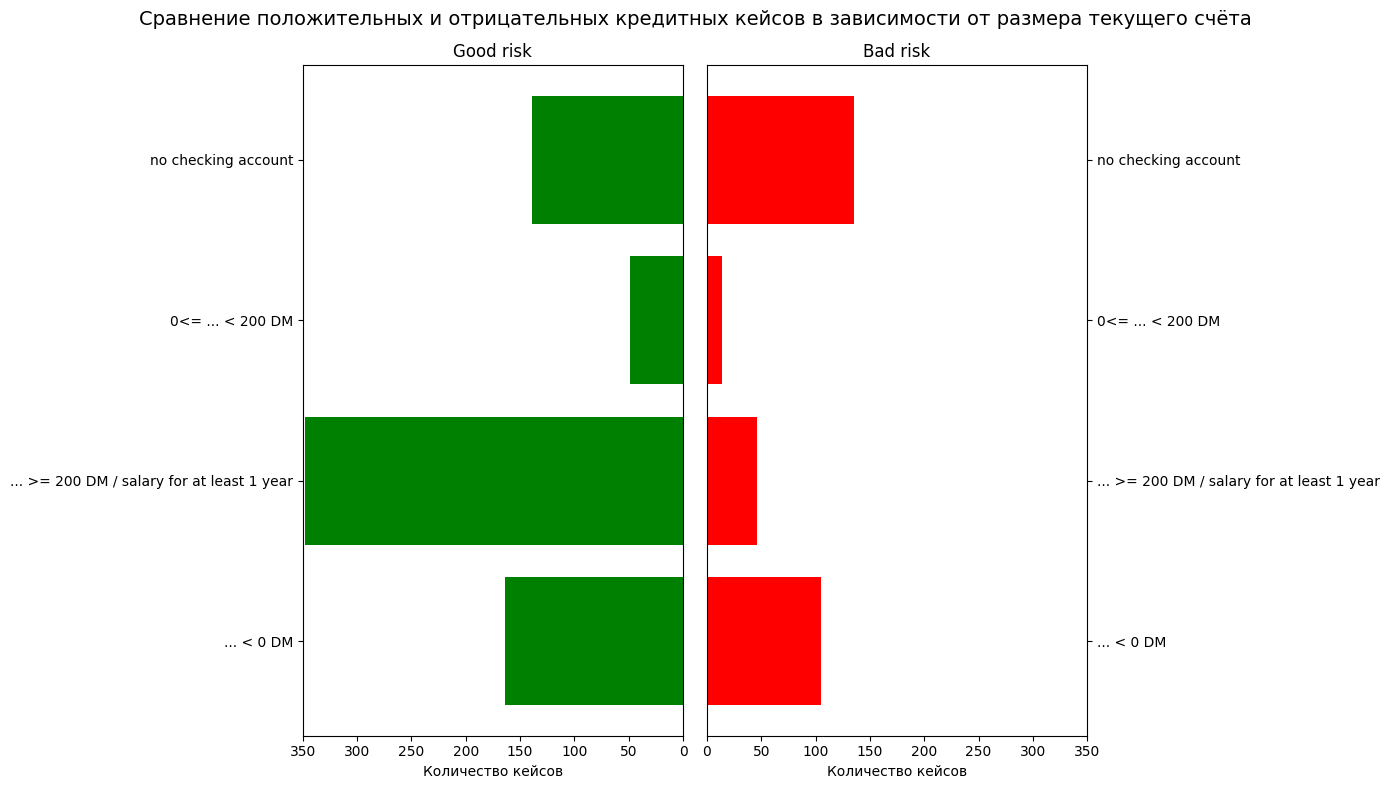

In [143]:

counts = (
     GERMAN_CREDIT_DF
    .groupby(["status", "credit_risk"])
    .size()
    .unstack(fill_value=0)
)

good = counts["good"]
bad = counts["bad"]
statuses = counts.index

real_max = max(good.max(), bad.max())
step = 50
x_max = ((real_max + step - 1) // step) * step
ticks = list(range(0, x_max + 1, step))

fig, (ax_good, ax_bad) = plt.subplots(
    ncols=2,
    figsize=(14, 8)
)


ax_good.barh(statuses, good, color="green")
ax_good.set_xlim(x_max, 0)
ax_good.set_xticks(ticks)
ax_good.set_title("Good risk")
ax_good.set_xlabel("Количество кейсов")

ax_bad.barh(statuses, bad, color="red")
ax_bad.set_xlim(0, x_max)
ax_bad.set_xticks(ticks)
ax_bad.set_title("Bad risk")
ax_bad.set_xlabel("Количество кейсов")


ax_bad.yaxis.tick_right()
ax_bad.tick_params(
    axis="y",
    labelright=True,
    labelleft=False,
)

fig.suptitle(
    "Сравнение положительных и отрицательных кредитных кейсов "
    "в зависимости от размера текущего счёта",
    fontsize=14
)

plt.tight_layout()
plt.show()


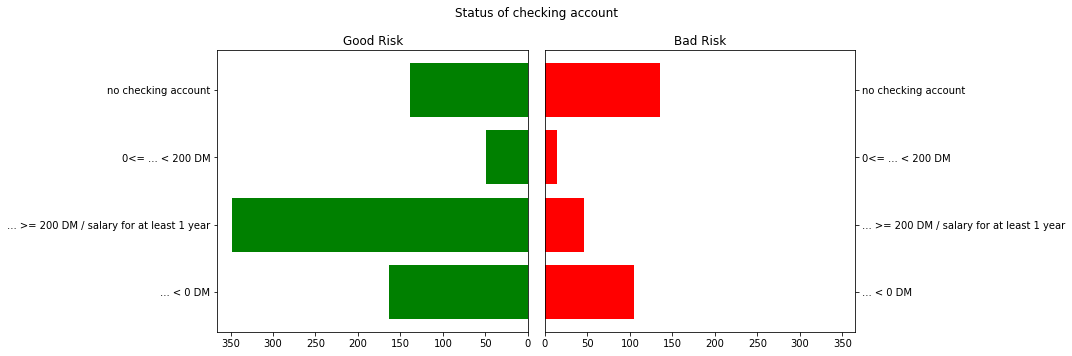

In [ ]:
# то что должно получиться

### Задание 3  (0.5 балла)

In [146]:
import seaborn as sns



```
# This is formatted as code
```

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

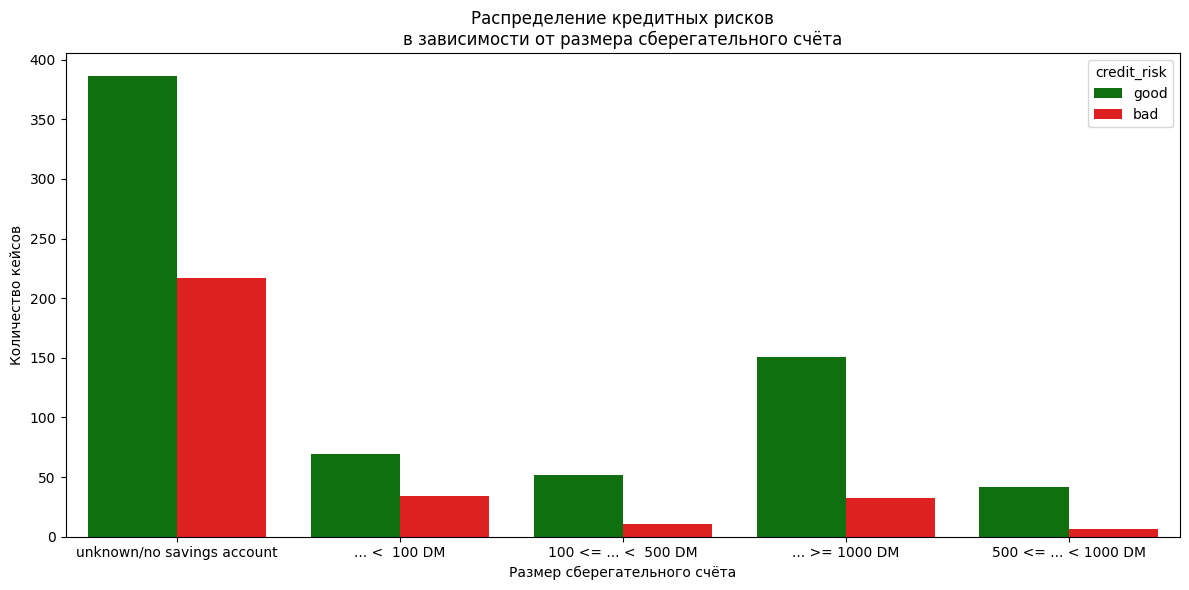

In [144]:
# ваш код здесь
plt.figure(figsize=(12, 6))
palette = {
    "good": "green",
    "bad": "red"
}
sns.countplot(
    data=GERMAN_CREDIT_DF,
    x="savings",
    hue="credit_risk",
    palette=palette
)

plt.title(
    "Распределение кредитных рисков в зависимости от размера сберегательного счёта"
)
plt.xlabel("Размер сберегательного счёта")
plt.ylabel("Количество кейсов")

plt.tight_layout()
plt.show()

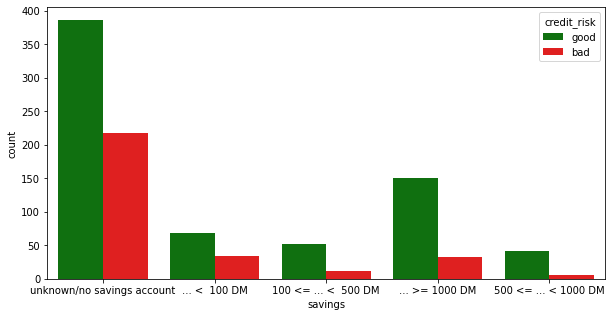

In [ ]:
# то что должно получиться

### Задание 4  (0.5 балла)

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

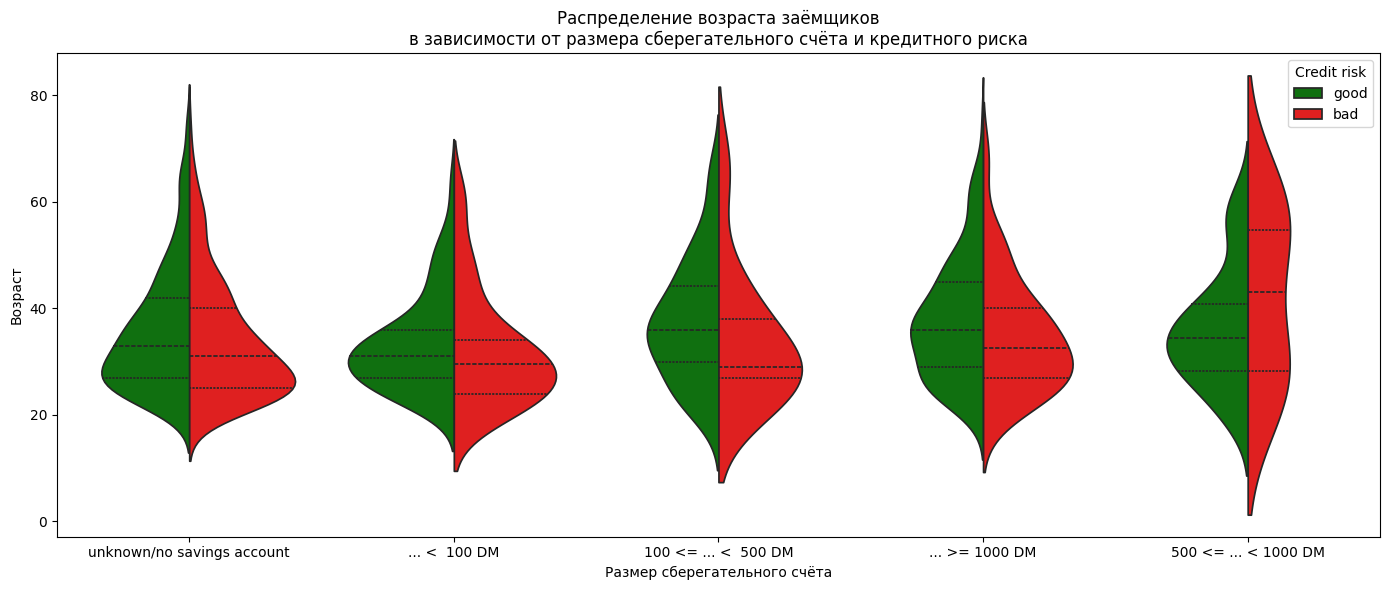

In [145]:
# ваш код здесь
palette = {
    "good": "green",
    "bad": "red"
}

plt.figure(figsize=(14, 6))

sns.violinplot(
    data=GERMAN_CREDIT_DF,
    x="savings",
    y="age",
    hue="credit_risk",
    palette=palette,
    split=True,
    inner="quartile"
)

plt.title(
    "Распределение возраста заёмщиков в зависимости от размера сберегательного счёта и кредитного риска"
)
plt.xlabel("Размер сберегательного счёта")
plt.ylabel("Возраст")

plt.legend(title="Credit risk")
plt.tight_layout()
plt.show()

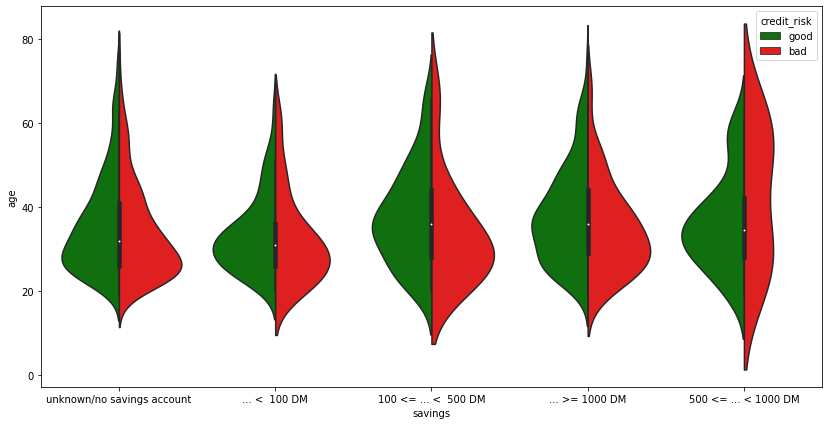

In [ ]:
# то что должно получиться

### Задание 5  (0.5 балла)

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

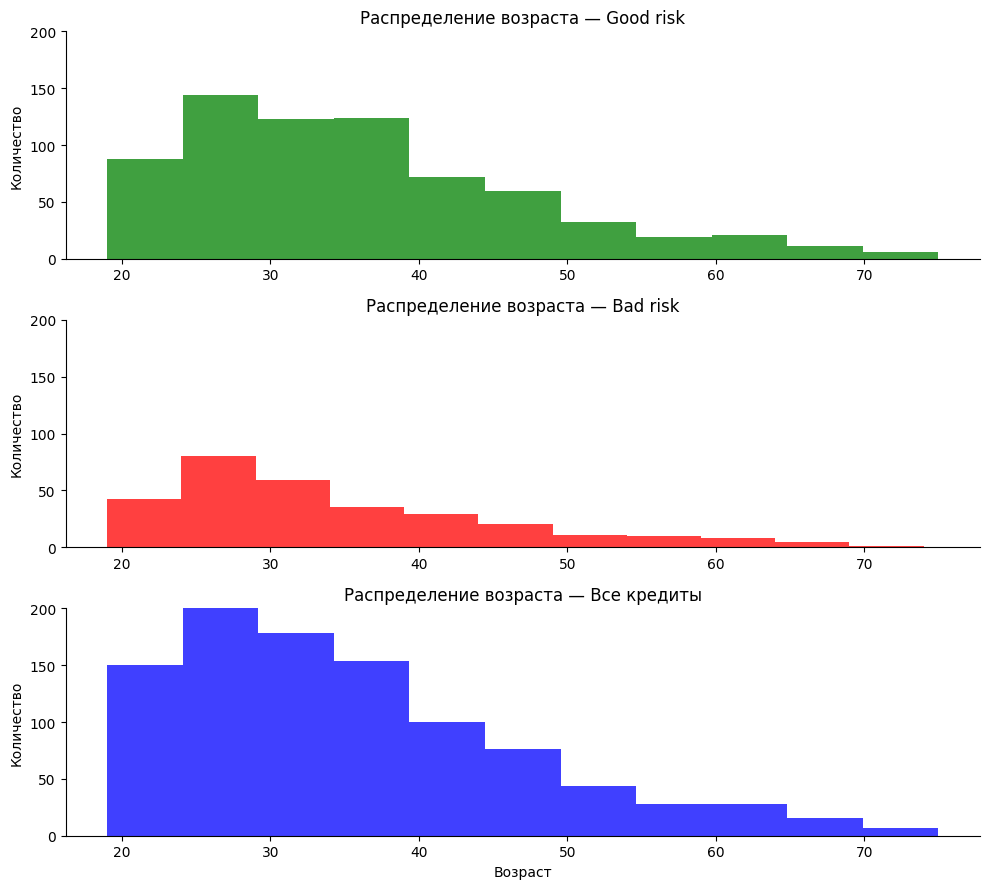

In [151]:
# ваш код здесь

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 9),
    sharex=True
)

y_max = 200
y_ticks = np.arange(0, y_max + 1, 50)

sns.histplot(
    data=GERMAN_CREDIT_DF[GERMAN_CREDIT_DF["credit_risk"] == "good"],
    x="age",
    color="green",
    binwidth=5,
    edgecolor=None,
    linewidth=0,
    ax=axes[0]
)
axes[0].set_ylim(0, y_max)
axes[0].set_yticks(y_ticks)
axes[0].set_title("Распределение возраста — Good risk")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", labelbottom=True)

sns.histplot(
    data=GERMAN_CREDIT_DF[GERMAN_CREDIT_DF["credit_risk"] == "bad"],
    x="age",
    color="red",
    binwidth=5,
    edgecolor=None,
    linewidth=0,
    ax=axes[1]
)
axes[1].set_ylim(0, y_max)
axes[1].set_yticks(y_ticks)
axes[1].set_title("Распределение возраста — Bad risk")
axes[1].set_ylabel("Количество")
axes[1].tick_params(axis="x", labelbottom=True)

sns.histplot(
    data=GERMAN_CREDIT_DF,
    x="age",
    color="blue",
    binwidth=5,
    edgecolor=None,
    linewidth=0,
    ax=axes[2]
)
axes[2].set_ylim(0, y_max)
axes[2].set_yticks(y_ticks)
axes[2].set_title("Распределение возраста — Все кредиты")
axes[2].set_xlabel("Возраст")
axes[2].set_ylabel("Количество")

sns.despine()
plt.tight_layout()
plt.show()


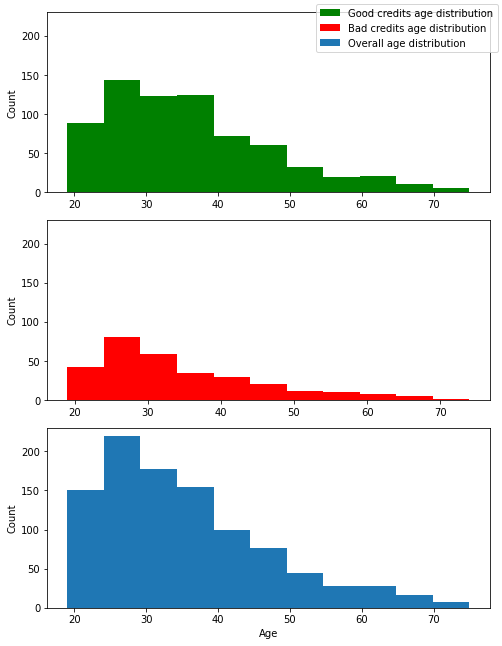

In [ ]:
# то что должно получиться

### Задание 6  (0.5 балла)

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

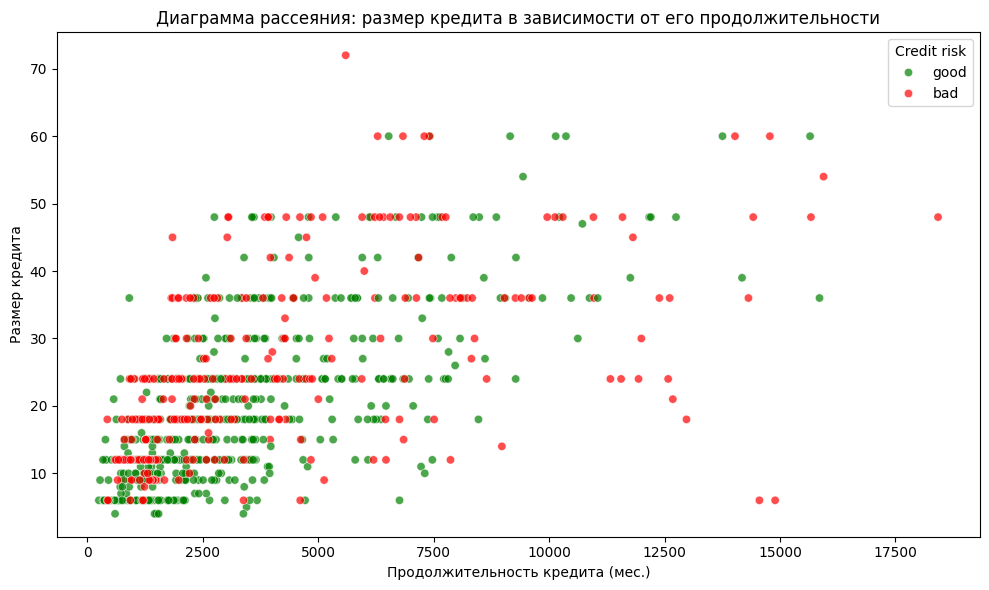

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "good": "green",
    "bad": "red"
}

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=GERMAN_CREDIT_DF,
    y="duration",
    x="amount",
    hue="credit_risk",
    palette=palette,
    alpha=0.7
)

plt.title(
    "Диаграмма рассеяния: размер кредита в зависимости от его продолжительности"
)
plt.xlabel("Продолжительность кредита (мес.)")
plt.ylabel("Размер кредита")

plt.legend(title="Credit risk")
plt.tight_layout()
plt.show()



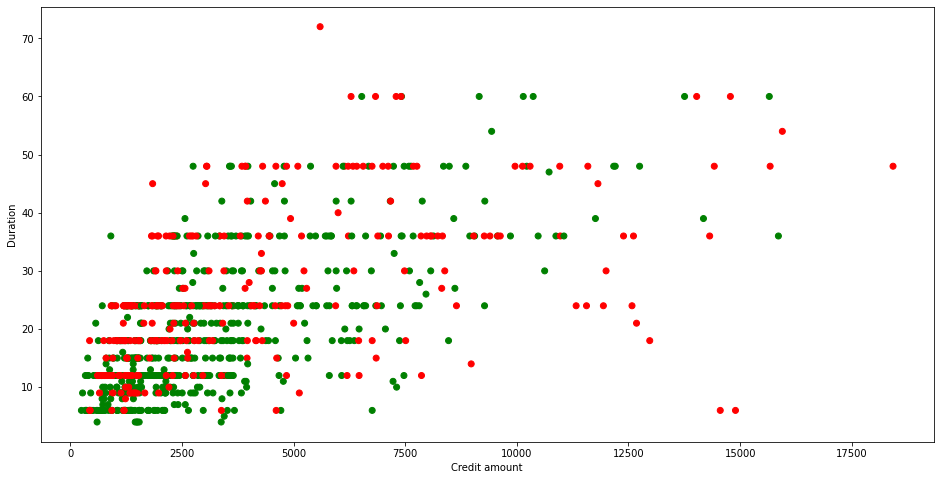

In [ ]:
# то что должно получиться

### Задание 7  (0.5 балла)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

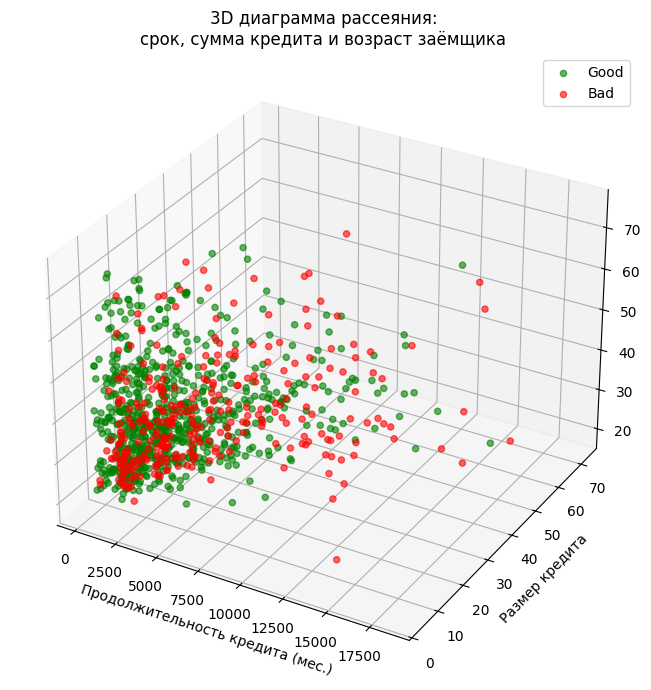

In [149]:
# ваш код здесь
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

good = GERMAN_CREDIT_DF[GERMAN_CREDIT_DF["credit_risk"] == "good"]
bad = GERMAN_CREDIT_DF[GERMAN_CREDIT_DF["credit_risk"] == "bad"]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    good["amount"],
    good["duration"],
    good["age"],
    c="green",
    alpha=0.6,
    label="Good"
)

ax.scatter(
    bad["amount"],
    bad["duration"],
    bad["age"],
    c="red",
    alpha=0.6,
    label="Bad"
)

ax.set_xlabel("Продолжительность кредита (мес.)")
ax.set_ylabel("Размер кредита")
ax.set_zlabel("Возраст")

ax.set_title(
    "3D диаграмма рассеяния:\nсрок, сумма кредита и возраст заёмщика"
)

ax.legend()
plt.tight_layout()
plt.show()


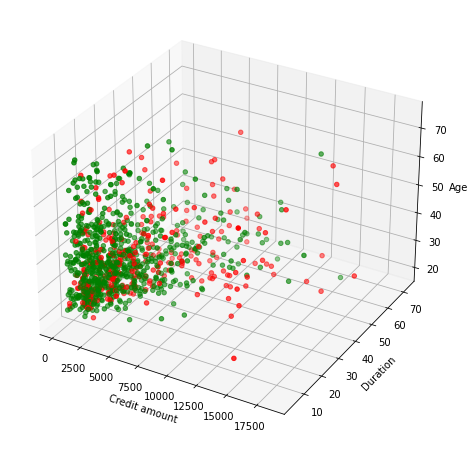

In [ ]:
# то что должно получиться

Что вы можете сказать о сравнении 3D- и 2D-визуализаций? Какие вы видите в них преимущества и недостатки?

Какие выводы с точки зрения бизнеса можно сделать из полученного графика?

**ВАШ ОТВЕТ**  

Преимущество 2D в простоте, такие графики легко воспринимаются, но содержат только две переменные в отличие от 3D. 3D позволяет искать сложные/скрытые закономерности, но построить такой график гораздо сложнее, многое зависет от выбранного угла обзора, точки могут накладываться друг на друга тем самым создавая визуальные искажения. 3D графики для инженеров, DS, 2D для менеджеров.

## Раздел 2. Визуализации в датасете Netflix

В данном разделе вы продолжите практиковаться в визуализациях и поработаете с более сложными графиками и инструментами.

Все технические рекомендации остаются неизменными с прошлого раздела.

In [154]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'
NETFLIX_TITLES_DF = pd.read_csv(NETFLIX_TITLES)
NETFLIX_TITLES_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


### Задание 1  (0.5 балла)

*Прочитайте* средствами pandas файл с данными Netflix. Посчитайте количество пропусков (NaN) в колонке `director`. Постройте столбчатую диаграмму, которая показывает 5 стран, в которых наибольшее количество фильмов содержат пропуски в столбце `director`.

Добавьте на диаграмму:

- Заголовок жирным шрифтом
- Подписи осей

Количество пропусков в колонке 'director': 2389


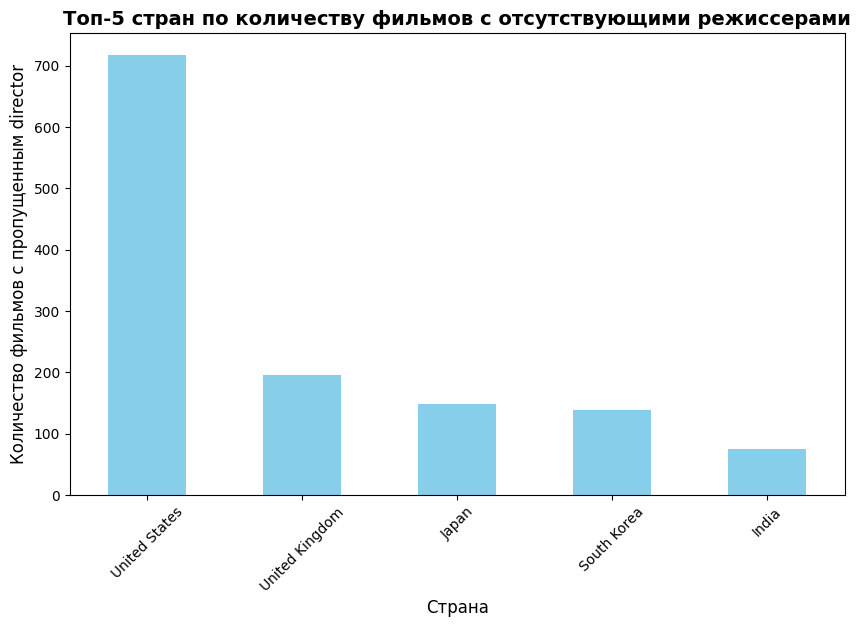

In [155]:
missing_director_count = NETFLIX_TITLES_DF['director'].isna().sum()
print(f"Количество пропусков в колонке 'director': {missing_director_count}")

missing_by_country = (NETFLIX_TITLES_DF[NETFLIX_TITLES_DF['director'].isna()]
                      .groupby('country').size())

top5_missing_countries = missing_by_country.sort_values(ascending=False).head(5)

plt.figure(figsize=(10,6))
top5_missing_countries.plot(kind='bar', color='skyblue')
plt.title("Топ-5 стран по количеству фильмов с отсутствующими режиссерами", fontsize=14, fontweight='bold')
plt.xlabel("Страна", fontsize=12)
plt.ylabel("Количество фильмов с пропущенным director", fontsize=12)
plt.xticks(rotation=45)
plt.show()


### Задание 2 (0.5 балла)

Постройте pie chart (круговую диаграмму), показывающую 5 стран, в которых произвели больше всего фильмов.

Добавьте на диаграмму:

+ Заголовок (Тип шрифта: ``family = 'monospace'``, насыщенность: ``fontweight='bold'``)
+ Название стран (Тип шрифта: ``family = 'monospace'``)
+ Подписи значений (%) (Тип шрифта: ``family = 'monospace'``)
+ Выберите стиль для диаграммы pastel c помощью библиотеки ``seaborn``

```colors = sns.color_palette('pastel')[0:5]```

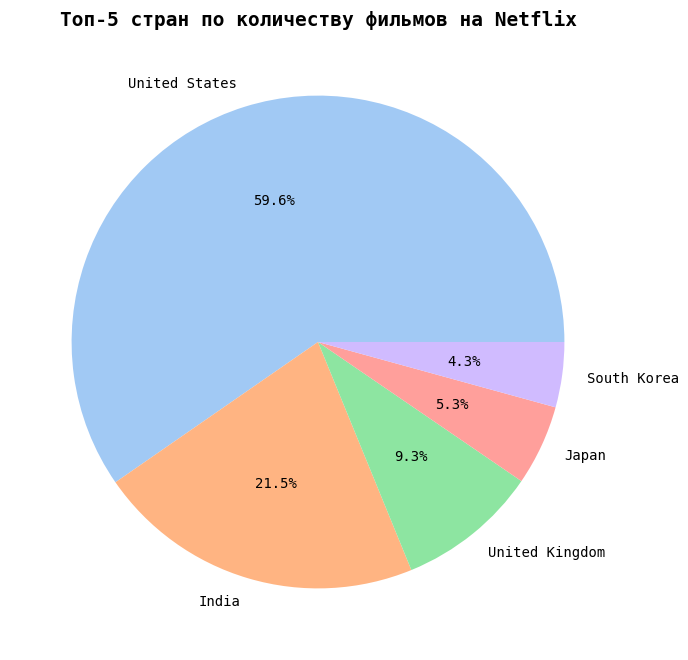

In [156]:
# ваш код здесь
top5_countries = NETFLIX_TITLES_DF['country'].value_counts().head(5)

colors = sns.color_palette('pastel')[0:5]

plt.figure(figsize=(8,8))
plt.pie(
    top5_countries,
    labels=top5_countries.index,
    autopct='%1.1f%%',
    colors=colors,
    textprops={'family':'monospace'}
)
plt.title(
    "Топ-5 стран по количеству фильмов на Netflix",
    family='monospace',
    fontweight='bold',
    fontsize=14
)
plt.show()

### Задание 3 (1 балл)

Постройте subplots, где на первом графике будет круговая диаграмма, показывающая долю фильмов каждого рейтинга *(rating)*, а на втором столбчатая диаграмма, показывающая 3 страны, в которых было снято больше всего фильмов с рейтингом TV-MA.

*Если фильмов в каких-то рейтингах меньше 50, то их в график брать не нужно.*

Добавьте на диаграммы:

+ Заголовки (можно жирным)

Круговая диаграмма:
+ Подписи значений абсолютные

Столбчатая диаграммма:
+ Сделайте так, чтобы ось Y была справа
+ Добавьте подпись «Количество фильмов» к оси Y и уберите подпись к оси X
+ Оставьте видимыми только правую и нижнюю границы

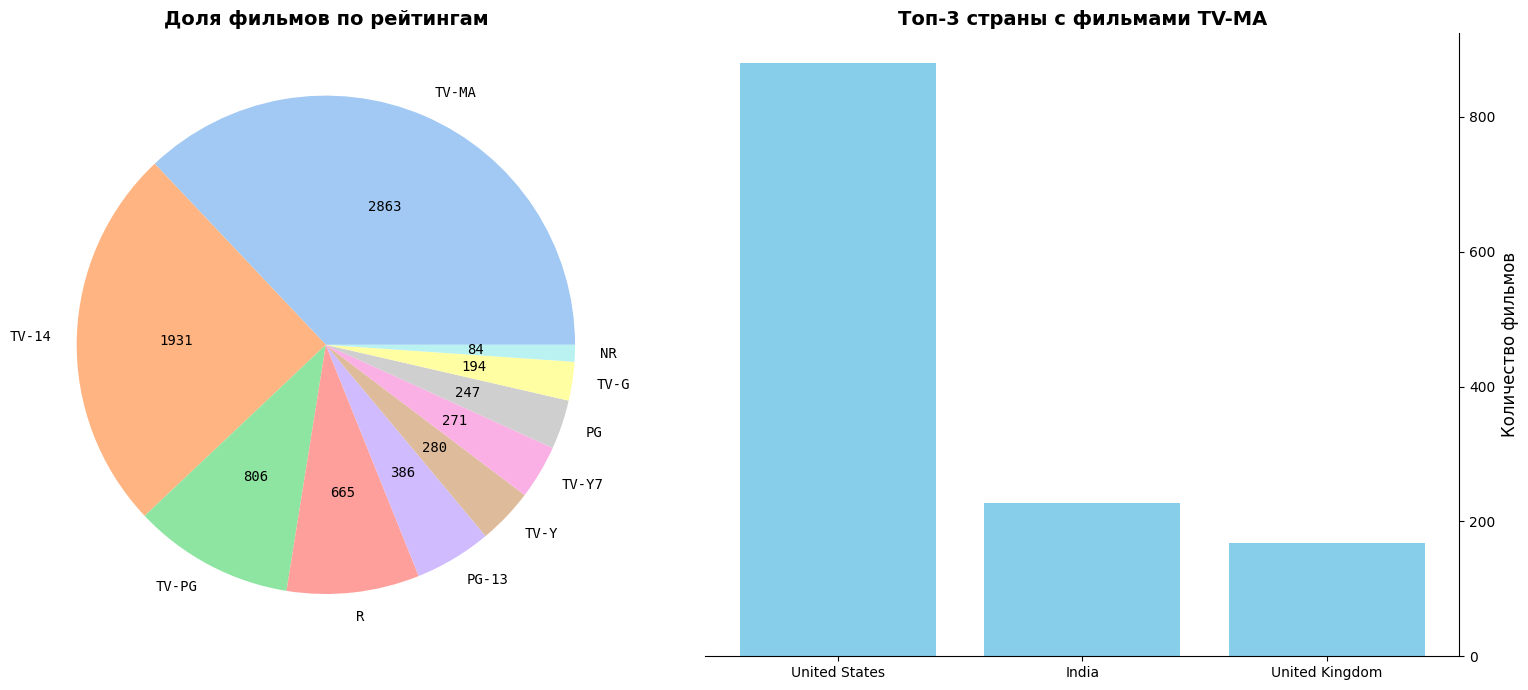

In [157]:
# ваш код здесь
rating_counts = NETFLIX_TITLES_DF['rating'].value_counts()
rating_counts = rating_counts[rating_counts >= 50]

tvma_df = NETFLIX_TITLES_DF[NETFLIX_TITLES_DF['rating'] == 'TV-MA']
tvma_top3 = tvma_df['country'].value_counts().head(3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

colors = sns.color_palette('pastel')[0:len(rating_counts)]
ax1.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct=lambda p: int(round(p*sum(rating_counts)/100)),
    colors=colors,
    textprops={'family':'monospace'}
)
ax1.set_title("Доля фильмов по рейтингам", fontweight='bold', fontsize=14)

bars = ax2.bar(tvma_top3.index, tvma_top3.values, color='skyblue')
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.set_ylabel("Количество фильмов", fontsize=12)
ax2.set_xlabel("")
ax2.set_title("Топ-3 страны с фильмами TV-MA", fontweight='bold', fontsize=14)

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Задание 4 (1 балл)

Преобразуйте колонку `date_added` в datetime. Создайте новые столбцы month и year из преобразованного столбца. Постройте линейный график: сколько в среднем фильмов было снято в каждый из месяцев.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Маркеры на точках перегиба
+ Настройте ось X: ось начинается с 1 заканчивается 12, шаг 1

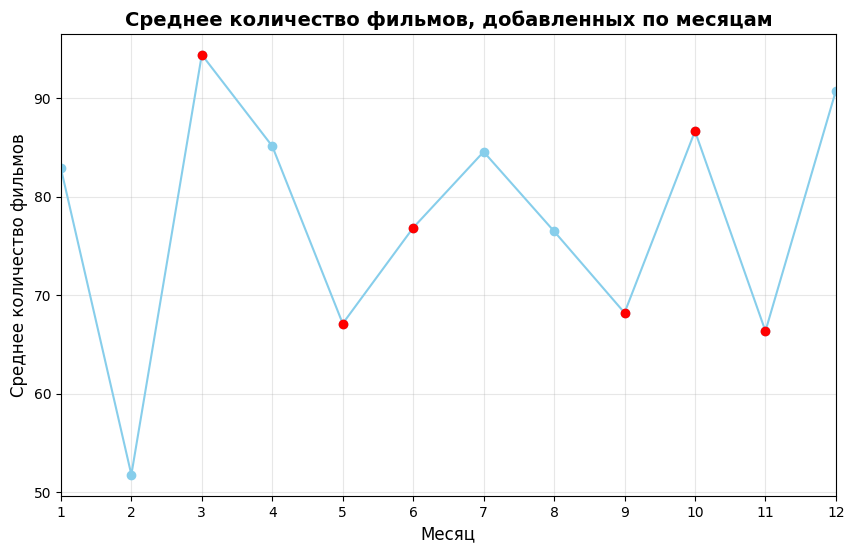

In [158]:
# ваш код здесь
df = NETFLIX_TITLES_DF
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['month'] = df['date_added'].dt.month
df['year'] = df['date_added'].dt.year

monthly_counts = df.groupby(['year', 'month']).size().reset_index(name='count')

avg_per_month = monthly_counts.groupby('month')['count'].mean()

plt.figure(figsize=(10,6))
plt.plot(avg_per_month.index, avg_per_month.values, marker='o', linestyle='-', color='skyblue')

y = avg_per_month.values
x = avg_per_month.index
dy = np.diff(y)
d2y = np.diff(dy)
inflection_points = [x[i+1] for i in range(1, len(d2y)) if d2y[i-1]*d2y[i] < 0]
plt.scatter(inflection_points, avg_per_month[inflection_points], color='red', zorder=5)

plt.title("Среднее количество фильмов, добавленных по месяцам", fontweight='bold', fontsize=14)
plt.xlabel("Месяц", fontsize=12)
plt.ylabel("Среднее количество фильмов", fontsize=12)

plt.xticks(range(1,13,1))
plt.xlim(1,12)

plt.grid(alpha=0.3)
plt.show()


### Задание 5 (1 балл)

Постройте линейный график, в какие годы (столбец year, который вы создали в задании 4) сколько фильмов было снято.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Измените цвет линии графика и сделайте ее пунктиром
+ Решетку на фон

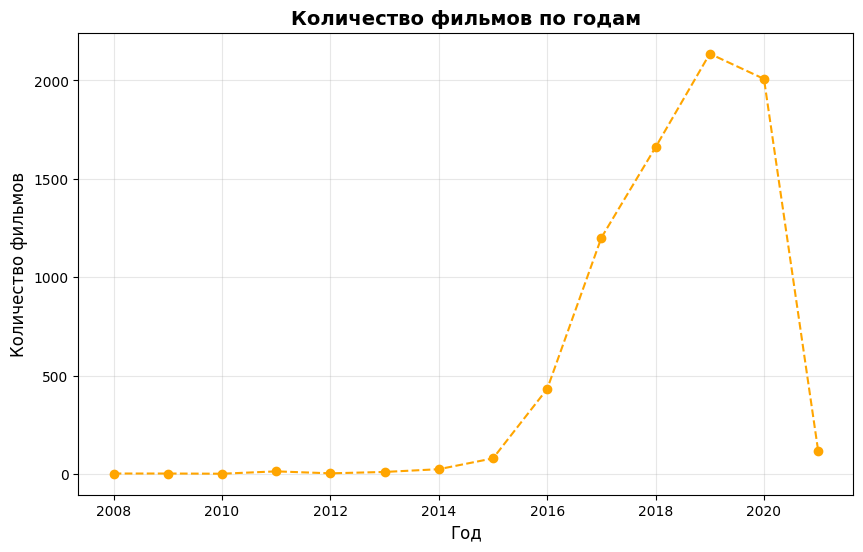

In [159]:
# ваш код здесь
df = NETFLIX_TITLES_DF
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year'] = df['date_added'].dt.year

yearly_counts = df.groupby('year').size().dropna()

plt.figure(figsize=(10,6))
plt.plot(yearly_counts.index, yearly_counts.values, color='orange', linestyle='--', marker='o')

plt.title("Количество фильмов по годам", fontweight='bold', fontsize=14)
plt.xlabel("Год", fontsize=12)
plt.ylabel("Количество фильмов", fontsize=12)

plt.grid(True, alpha=0.3)
plt.show()

### Задание 6 (1 балл)

Будем работать со столбцом duration. Одни данные даны в минутах (для фильмов (Movie)), а другие в сезонах (для сериалов (TV shows)). Создайте два новых столбца min (для тех, у кого продолжительность в минутах) и season (для тех, у кого продолжительность в сезонах), в которых будут извлечены данные из столбца duration.

Постройте subplots, где на первом графике гистрограмма распределения продолжительности фильмов, а на втором – гистрограмма распределения продолжительности сериалов.

Добавьте на графики:

+ Заголовки жирным шрифтом
+ Подписи осей

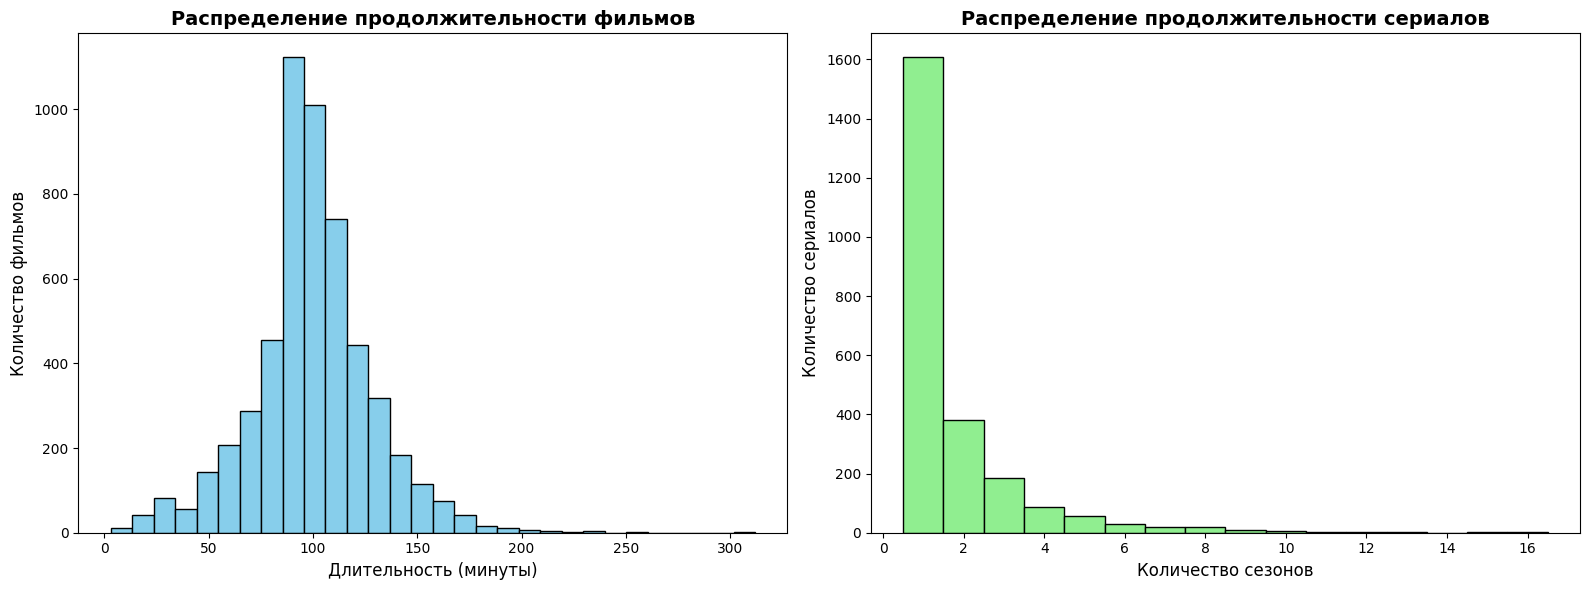

In [161]:
# ваш код здесь
df = NETFLIX_TITLES_DF
df['min'] = df.apply(lambda row: int(row['duration'].replace(' min',''))
                     if row['type'] == 'Movie' and pd.notna(row['duration']) else None, axis=1)

def extract_season(value):
    if pd.isna(value):
        return None
    value = value.replace(' Season','').replace('s','')
    try:
        return int(value)
    except:
        return None

df['season'] = df.apply(lambda row: extract_season(row['duration'])
                        if row['type'] == 'TV Show' else None, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

ax1.hist(df['min'].dropna(), bins=30, color='skyblue', edgecolor='black')
ax1.set_title("Распределение продолжительности фильмов", fontweight='bold', fontsize=14)
ax1.set_xlabel("Длительность (минуты)", fontsize=12)
ax1.set_ylabel("Количество фильмов", fontsize=12)

season_values = df['season'].dropna().astype(int)
ax2.hist(season_values, bins=range(1, season_values.max()+2), color='lightgreen', edgecolor='black', align='left')
ax2.set_title("Распределение продолжительности сериалов", fontweight='bold', fontsize=14)
ax2.set_xlabel("Количество сезонов", fontsize=12)
ax2.set_ylabel("Количество сериалов", fontsize=12)

plt.tight_layout()
plt.show()

### Задание 7 (0.5 балла)

Постройте ящик с усами (box plot) по продолжительности фильмов (Movies). Визуально проинтерпретируйте его.

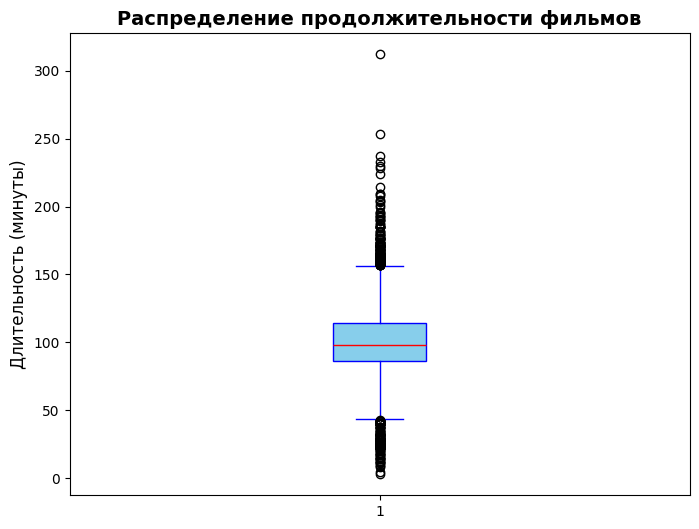

In [162]:
# ваш код здесь
df = NETFLIX_TITLES_DF
df['min'] = df.apply(lambda row: int(row['duration'].replace(' min',''))
                     if row['type'] == 'Movie' and pd.notna(row['duration']) else None, axis=1)

movie_durations = df['min'].dropna()

plt.figure(figsize=(8,6))
plt.boxplot(movie_durations, vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue', color='blue'),
            medianprops=dict(color='red'), whiskerprops=dict(color='blue'), capprops=dict(color='blue'))
plt.title("Распределение продолжительности фильмов", fontweight='bold', fontsize=14)
plt.ylabel("Длительность (минуты)", fontsize=12)
plt.show()


### Задание 8* (1 балл)

Постройте при помощи библиотеки plotly интерактивную столбчатую диаграмму, которая сравнивает среднюю продолжительность фильмов и сериалов за каждый год, начиная с 2000.

In [164]:
import plotly.graph_objects as go

# ваш код здесь
df = NETFLIX_TITLES_DF
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year'] = df['date_added'].dt.year

df['min'] = df.apply(lambda row: int(row['duration'].replace(' min',''))
                     if row['type'] == 'Movie' and pd.notna(row['duration']) else None, axis=1)
df['season'] = df.apply(lambda row: int(row['duration'].replace(' Season','').replace('s',''))
                        if row['type'] == 'TV Show' and pd.notna(row['duration']) else None, axis=1)

df_filtered = df[df['year'] >= 2000]

avg_duration = df_filtered.groupby(['year', 'type']).agg({'min':'mean','season':'mean'}).reset_index()

avg_duration['avg'] = avg_duration.apply(lambda row: row['min'] if row['type']=='Movie' else row['season'], axis=1)

movies = avg_duration[avg_duration['type']=='Movie']
tvshows = avg_duration[avg_duration['type']=='TV Show']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=movies['year'],
    y=movies['avg'],
    name='Movies',
    marker_color='skyblue'
))

fig.add_trace(go.Bar(
    x=tvshows['year'],
    y=tvshows['avg'],
    name='TV Shows',
    marker_color='lightgreen'
))

fig.update_layout(
    barmode='group',
    title=dict(text='Средняя продолжительность фильмов и сериалов по годам', font=dict(size=16, family='Arial', color='black'), x=0.5),
    xaxis_title='Год',
    yaxis_title='Средняя продолжительность (минуты/сезоны)',
    xaxis=dict(dtick=1),
    template='plotly_white'
)

fig.show()